#### Off-State Breakdown at High Voltage

This script evaluates the breakdown voltage ($V_{DS, BD}$) by ramping drain bias ($V_{DS}$) under hard pinch-off (highly negative $V_{GS}$). 

* Impact Ionization (Avalanche Breakdown): The massive voltage drop across the depleted channel creates an extreme local electric field. If this field exceeds the material's critical limit ($E_{crit}$), residual electrons gain immense kinetic energy and collide with the crystal lattice, generating electron-hole pairs. 
* Ionization Rate & Criterion: Modeled via Chynoweth's law:
  $$\alpha_n(E) = A_n \exp\left(-\frac{B_n}{E}\right)$$
  Breakdown is formally triggered when the integrated impact ionization current reaches the threshold condition:
  $$I_{ion} = \int_{0}^{L_{ch}} \alpha_n(x) \, dx \geq 1.0 \quad \text{or} \quad \max(E_{channel}) \geq E_{crit}$$
  This sudden flood of charge causes an uncontrollable current spike, permanently destroying the device's ability to block voltage.


              ADAPTIVE BINARY SEARCH BREAKDOWN SOLVER (V_DS,BD)               

[Step 1/10] Testing Vds = 51.00 V  | Current Window: [2.00 V - 100.00 V]
------------------------------------------------------------------------------
    ↳ [Iter   0] err_phi: 5.11e+01 | I_d:    0.000 mA/mm | T_max:  300.0 K
    ↳ [Iter  20] err_phi: 1.83e+01 | I_d:  534.917 mA/mm | T_max:  303.7 K
    ↳ [Iter  40] err_phi: 6.57e+00 | I_d:  553.704 mA/mm | T_max:  307.7 K
    ↳ [Iter  60] err_phi: 2.36e+00 | I_d:  970.040 mA/mm | T_max:  311.7 K
    ↳ [Iter  80] err_phi: 8.45e-01 | I_d: 1045.620 mA/mm | T_max:  315.7 K
    ↳ [Iter 100] err_phi: 3.03e-01 | I_d:  540.495 mA/mm | T_max:  319.7 K
    ↳ [Iter 120] err_phi: 2.38e-01 | I_d:  469.671 mA/mm | T_max:  323.7 K
    ↳ [Iter 140] err_phi: 2.10e-01 | I_d:  525.558 mA/mm | T_max:  327.7 K
    ↳ [Iter 160] err_phi: 2.89e-01 | I_d:  531.533 mA/mm | T_max:  331.7 K
    ↳ [Iter 180] err_phi: 2.80e-01 | I_d:  525.002 mA/mm | T_max:  335.7 K
    ↳ [Iter 200] 

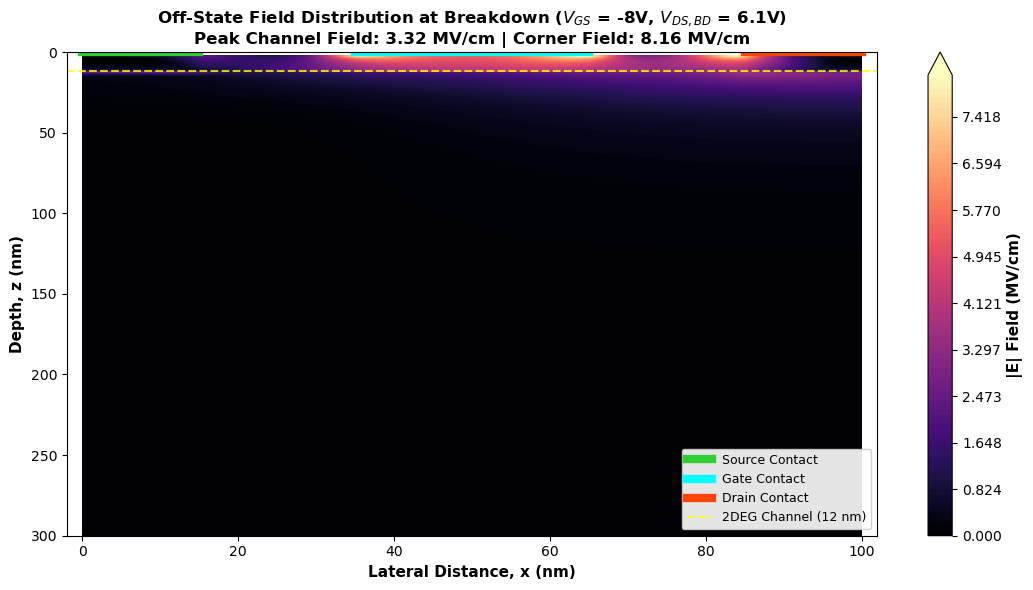

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as spla
import scipy.linalg as la
import scipy.constants as const

# 1. PHYSICAL PARAMETERS & MATERIAL PROPERTIES

q = const.e
hbar = const.hbar
eps0 = const.epsilon_0
kB = const.k
T_amb = 300.0        # Ambient temperature (K)
m0 = const.m_e

# HEMT Operating Conditions
x_al = 0.22          # 22% Al Content
V_schottky = 1.2     # Schottky barrier height (V)
V_surface_pin = -1.2 # Fermi pinning level in access regions (V)
Vg_current = -8      # Target Off-State Gate Bias (V)

# Breakdown Criteria Parameters
E_crit_channel = 3.3  # Critical electric field threshold for GaN 2DEG (MV/cm)
A_n_ion = 2.9e8       # Impact ionization pre-factor (1/m)
B_n_ion = 3.4e9       # Impact ionization critical field (V/m)

# Transport Physics Parameters
mu_0 = 0.12          # Calibrated 2DEG low-field mobility at 300K (m^2/Vs)
v_sat_300K = 1.1e5   # Effective saturation velocity in GaN at 300K (m/s)
beta_CT = 2.0        # Caughey-Thomas empirical beta

# Thermal Parameters
kappa_GaN = 130.0    # Thermal conductivity of GaN (W/m-K)
kappa_AlGaN = 20.0   # Thermal conductivity of AlGaN (W/m-K)
gamma_mu = 2.0       # Temperature exponent for mobility degradation
gamma_vsat = 1.5     # Temperature exponent for vsat degradation

# Deep Buffer Trap Parameters
E_dA = 2.5 * q       
g_A = 4.0            

# Material parameters
m_GaN = 0.20 * m0
m_AlGaN = (0.32 * x_al + 0.20 * (1.0 - x_al)) * m0
eps_GaN = 8.9 * eps0
eps_AlGaN = (8.5 * x_al + 8.9 * (1.0 - x_al)) * eps0
dE_c = 0.7 * (3.07 * x_al + 0.7 * x_al * (1.0 - x_al)) * q  

# Spontaneous & Piezoelectric Polarization Calculation
P_SP_GaN = -0.034
P_SP_AlGaN = -0.090 * x_al - 0.034 * (1.0 - x_al) + 0.021 * x_al * (1.0 - x_al)
a_GaN, a_AlN = 0.3189e-9, 0.3112e-9
a_AlGaN = a_AlN * x_al + a_GaN * (1.0 - x_al)
strain_inplane = (a_GaN - a_AlGaN) / a_AlGaN
e31 = -0.11 * x_al - 0.49 * (1.0 - x_al)
e33 = 0.73 * x_al + 0.97 * (1.0 - x_al)
C13 = (103 * x_al + 106 * (1.0 - x_al)) * 1e9
C33 = (405 * x_al + 398 * (1.0 - x_al)) * 1e9
P_PE_AlGaN = 2 * strain_inplane * (e31 - e33 * (C13 / C33))
sigma_pol = (P_SP_GaN - (P_SP_AlGaN + P_PE_AlGaN)) / q  


# 2. DEVICE TOPOLOGY & MESH GENERATION
L_s, L_sg, L_g, L_gd, L_d = 15e-9, 20e-9, 30e-9, 20e-9, 15e-9
Lx = L_s + L_sg + L_g + L_gd + L_d
t_barrier, t_buffer = 12.0e-9, 288.0e-9 
Lz = t_barrier + t_buffer  # Total depth = 300 nm

z_top = np.linspace(0, 9e-9, 15, endpoint=False)
z_2deg = np.linspace(9e-9, 18e-9, 65, endpoint=False) 
z_buf = np.geomspace(18e-9, Lz, 40)
z = np.unique(np.sort(np.concatenate([z_top, z_2deg, z_buf])))
Nz = len(z)

x_gate1 = L_s + L_sg
x_gate2 = x_gate1 + L_g
x_s = np.linspace(0, L_s, 10, endpoint=False)
x_sg = np.linspace(L_s, x_gate1, 15, endpoint=False)
x_g = np.linspace(x_gate1, x_gate2, 25, endpoint=False)
x_gd = np.linspace(x_gate2, Lx - L_d, 15, endpoint=False)
x_d = np.linspace(Lx - L_d, Lx, 15)
x = np.unique(np.sort(np.concatenate([x_s, x_sg, x_g, x_gd, x_d])))
Nx = len(x)

X, Z = np.meshgrid(x, z)
idx_int = np.argmin(np.abs(z - t_barrier))

dx_R = np.diff(x); dx_L = np.roll(dx_R, 1)                  
dx_avg = 0.5 * (np.append(dx_R, dx_R[-1]) + np.insert(dx_L, 0, dx_L[0]))
dz_R = np.diff(z); dz_L = np.roll(dz_R, 1)                  
dz_avg = 0.5 * (np.append(dz_R, dz_R[-1]) + np.insert(dz_L, 0, dz_L[0]))

m_eff = np.where(Z <= t_barrier, m_AlGaN, m_GaN)
eps_r = np.where(Z <= t_barrier, eps_AlGaN, eps_GaN)
kappa_grid = np.where(Z <= t_barrier, kappa_AlGaN, kappa_GaN)
V_band = np.where(Z <= t_barrier, dE_c, 0.0)

source_mask = (X <= L_s) & (Z == 0)
gate_mask = (X >= x_gate1) & (X <= x_gate2) & (Z == 0)
drain_mask = (X >= Lx - L_d) & (Z == 0)


# 3. DOPING
rho_fixed = np.zeros((Nz, Nx))
rho_fixed[idx_int+1:, :] += q * 1e22 
rho_fixed[idx_int, :] += (q * sigma_pol) / dz_avg[idx_int]

N_D_contacts = 2e25 
contact_depth = t_barrier + 2e-9
rho_fixed[(X <= L_s) & (Z <= contact_depth)] += q * N_D_contacts
rho_fixed[(X >= Lx - L_d) & (Z <= contact_depth)] += q * N_D_contacts

t_buffer_doped_start = t_barrier + 20e-9
idx_buffer_doped = np.max(np.where(z <= t_buffer_doped_start)[0])
N_acceptor = 5e22 

buf_trap_mask = np.zeros((Nz, Nx), dtype=bool)
buf_trap_mask[idx_buffer_doped:, :] = True

N_C_GaN = 2.0 * ((m_GaN * kB * T_amb) / (2.0 * np.pi * hbar**2))**1.5 
n_ratio = N_D_contacts / N_C_GaN
V_bi = (kB * T_amb / q) * (np.log(n_ratio) + n_ratio / np.sqrt(8))


# 4. 2D MATRICES (POISSON & THERMAL)
N_tot = Nx * Nz
A_poisson_base = sparse.lil_matrix((N_tot, N_tot))
A_therm_base = sparse.lil_matrix((N_tot, N_tot))

def get_k(i, j): return j * Nx + i

for j in range(Nz):
    for i in range(Nx):
        k = get_k(i, j)
        
        # Poisson Stencil Setup
        if gate_mask[j, i] or source_mask[j, i] or drain_mask[j, i] or j == 0:
            A_poisson_base[k, k] = 1.0
        elif j == Nz - 1: 
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i, j-1)] = -1.0
        elif i == 0:      
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i+1, j)] = -1.0
        elif i == Nx - 1: 
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i-1, j)] = -1.0
        else:
            dx_r_i, dx_l_i, dx_a_i = dx_R[i], dx_R[i-1], dx_avg[i]
            dz_r_j, dz_l_j, dz_a_j = dz_R[j], dz_R[j-1], dz_avg[j]
            
            exP = 0.5 * (eps_r[j, i] + eps_r[j, i+1]); exM = 0.5 * (eps_r[j, i] + eps_r[j, i-1])
            ezP = 0.5 * (eps_r[j, i] + eps_r[j+1, i]); ezM = 0.5 * (eps_r[j, i] + eps_r[j-1, i])
            c_iP, c_iM = exP / (dx_a_i * dx_r_i), exM / (dx_a_i * dx_l_i)
            c_jP, c_jM = ezP / (dz_a_j * dz_r_j), ezM / (dz_a_j * dz_l_j)
            A_poisson_base[k, get_k(i+1, j)] = c_iP; A_poisson_base[k, get_k(i-1, j)] = c_iM
            A_poisson_base[k, get_k(i, j+1)] = c_jP; A_poisson_base[k, get_k(i, j-1)] = c_jM
            A_poisson_base[k, k] = -(c_iP + c_iM + c_jP + c_jM)

        # Thermal Stencil Setup
        if j == Nz - 1:   
            A_therm_base[k, k] = 1.0
        elif i == 0:      
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i+1, j)] = -1.0
        elif i == Nx - 1: 
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i-1, j)] = -1.0
        elif j == 0:      
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i, j+1)] = -1.0
        else:
            dx_r_i, dx_l_i, dx_a_i = dx_R[i], dx_R[i-1], dx_avg[i]
            dz_r_j, dz_l_j, dz_a_j = dz_R[j], dz_R[j-1], dz_avg[j]
            
            kxP = 0.5 * (kappa_grid[j, i] + kappa_grid[j, i+1]); kxM = 0.5 * (kappa_grid[j, i] + kappa_grid[j, i-1])
            kzP = 0.5 * (kappa_grid[j, i] + kappa_grid[j+1, i]); kzM = 0.5 * (kappa_grid[j, i] + kappa_grid[j-1, i])
            tc_iP, tc_iM = kxP / (dx_a_i * dx_r_i), kxM / (dx_a_i * dx_l_i)
            tc_jP, tc_jM = kzP / (dz_a_j * dz_r_j), kzM / (dz_a_j * dz_l_j)
            A_therm_base[k, get_k(i+1, j)] = tc_iP; A_therm_base[k, get_k(i-1, j)] = tc_iM
            A_therm_base[k, get_k(i, j+1)] = tc_jP; A_therm_base[k, get_k(i, j-1)] = tc_jM
            A_therm_base[k, k] = -(tc_iP + tc_iM + tc_jP + tc_jM)

A_csr = A_poisson_base.tocsr()
A_therm_csr = A_therm_base.tocsr()


# 5. ADAPTIVE BINARY SEARCH BREAKDOWN SOLVER
print("\n" + "="*78)
print(f"{'ADAPTIVE BINARY SEARCH BREAKDOWN SOLVER (V_DS,BD)':^78}")
print("="*78)

# SEARCH RANGE & TOLERANCE
V_low = 2           # Lower bound (V)
V_high = 100        # Upper bound (V)
voltage_tol = 0.05  # Stop criterion narrowed to 50 mV precision
max_binary_steps = 10 # Search depth

# Warm Start Variables
phi = np.zeros((Nz, Nx))
n_2d = np.zeros((Nz, Nx))
T_2d = np.full((Nz, Nx), T_amb)
T_channel = np.full(Nx, T_amb)
V_tot = np.copy(V_band)
V_ef_lat = np.zeros(Nx)

idx_qbox = np.argmin(np.abs(z - (t_barrier + 95.0e-9)))

dirichlet_mask = gate_mask | source_mask | drain_mask
surface_pin_mask = (Z == 0) & ~dirichlet_mask
outer_bc_mask = ((Z == Lz) | (X == 0) | (X == Lx)) & (Z > 0)
interior_mask = ~(dirichlet_mask | surface_pin_mask | outer_bc_mask)

N_DOS_3D_equiv = np.broadcast_to((m_GaN * kB * T_amb) / (np.pi * hbar**2 * dz_avg[:, np.newaxis]), (Nz, Nx))

alpha_p, alpha_n, alpha_EF, alpha_T = 0.05, 0.025, 0.025, 0.02


min_iters = 150
max_step_iters = 700
n_subbands = 3
convergence_tol = 1e-4     # mA/mm tolerance

search_history = []
last_breakdown_phi = None
last_breakdown_Vds = None

for search_step in range(max_binary_steps):
    Vds_test = 0.5 * (V_low + V_high)
    print(f"\n[Step {search_step+1}/{max_binary_steps}] Testing Vds = {Vds_test:.2f} V  | Current Window: [{V_low:.2f} V - {V_high:.2f} V]")
    print("-" * 78)
    
    b_base_2d = np.zeros((Nz, Nx))
    b_base_2d[gate_mask] = Vg_current - (V_schottky - dE_c / q)
    b_base_2d[source_mask] = V_bi
    b_base_2d[drain_mask] = Vds_test + V_bi
    b_base_2d[surface_pin_mask] = V_surface_pin
    
    V_ef_lat = np.linspace(0, Vds_test, Nx)
    E_F_lat = -q * V_ef_lat
    
    Id_history = []
    I_d_channel = np.zeros(Nx)
    
    for iteration in range(max_step_iters):
        # Poisson Block
        b_2d = np.copy(b_base_2d)
        E_C = V_band - q * phi
        E_A = E_C - E_dA
        E_Fn = E_F_lat[np.newaxis, :] 
        
        exp_term_A = g_A * np.exp(np.clip((E_A - E_Fn) / (kB * T_amb), -700.0, 700.0))
        f_A = 1.0 / (1.0 + exp_term_A) 
        
        rho_trap = np.zeros((Nz, Nx))
        rho_trap[buf_trap_mask] = -q * N_acceptor * f_A[buf_trap_mask]
        
        rho_total = rho_fixed + rho_trap
        b_2d[interior_mask] = -(rho_total[interior_mask] - q * n_2d[interior_mask])
        
        term_n = np.exp(-np.minimum(n_2d[interior_mask] / N_DOS_3D_equiv[interior_mask], 700.0))
        D_electrons = (q**2 * N_DOS_3D_equiv[interior_mask] / (kB * T_amb)) * (1.0 - term_n)
        
        exp_A_sub = exp_term_A[buf_trap_mask]
        exp_safe = np.minimum(exp_A_sub, 1e15)
        df_dE = np.where(exp_A_sub > 1e15, 0.0, exp_safe / (1.0 + exp_safe)**2)
        
        D_traps = np.zeros((Nz, Nx))
        D_traps[buf_trap_mask] = (q**2 * N_acceptor / (kB * T_amb)) * df_dE
        
        D_gummel_2d = np.zeros((Nz, Nx))
        D_gummel_2d[interior_mask] = D_electrons + D_traps[interior_mask]
        
        D_gummel_flat = D_gummel_2d.flatten()
        A_gummel_dynamic = A_csr - sparse.diags(D_gummel_flat, format='csr')
        b_gummel_dynamic = b_2d.flatten() - D_gummel_flat * phi.flatten()
        
        phi_new = spla.spsolve(A_gummel_dynamic, b_gummel_dynamic).reshape((Nz, Nx))
        err_phi = np.max(np.abs(phi_new - phi))
        
        phi = alpha_p * phi_new + (1 - alpha_p) * phi
        V_tot = np.clip(V_band - q * phi, -100.0*q, 100.0*q) 
        
        # Schrödinger Block
        n_new = np.zeros((Nz, Nx))
        V_xc_raw = -(q**2 / (4.0 * np.pi * eps_r)) * (3.0 * np.maximum(n_2d, 1e12) / np.pi)**(1.0 / 3.0)
        V_xc = np.clip(V_xc_raw, -0.05 * q, 0.0)
        V_quantum_2d = V_tot + V_xc
        N_int = idx_qbox - 2
        
        for i in range(Nx):
            V_quantum = V_quantum_2d[:idx_qbox, i]; m_col = m_eff[:idx_qbox, i]
            d_int = np.zeros(N_int); e_int = np.zeros(N_int - 1)
            
            for k in range(N_int):
                j = k + 1
                dz_r, dz_l, dz_a = dz_R[j], dz_R[j-1], dz_avg[j]
                inv_mp, inv_mm = 0.5*(1.0/m_col[j] + 1.0/m_col[j+1]), 0.5*(1.0/m_col[j] + 1.0/m_col[j-1])
                d_int[k] = V_quantum[j] + (hbar**2 / (2.0 * dz_a)) * (inv_mp / dz_r + inv_mm / dz_l)
                if k < N_int - 1:
                    e_int[k] = -(hbar**2 / 2.0) * (inv_mp / dz_r) / np.sqrt(dz_a * dz_avg[j+1])
            
            evals, evecs_int = la.eigh_tridiagonal(d_int, e_int, select='i', select_range=(0, n_subbands-1))
            evecs_full = np.zeros((idx_qbox, n_subbands))
            evecs_full[1:-1, :] = evecs_int
            
            for m in range(n_subbands):
                m_eff_subband = m_GaN * (1.0 + (0.6/q) * np.maximum(evals[m] - V_quantum[idx_int], 0.0))
                n_s = ((m_eff_subband * kB * T_amb) / (np.pi * hbar**2)) * np.logaddexp(0, (E_F_lat[i] - evals[m]) / (kB * T_amb))
                u_sq = evecs_full[:, m]**2
                psi_sq = (u_sq / dz_avg[:idx_qbox]) / np.sum(u_sq)
                psi_sq_full = np.zeros(Nz); psi_sq_full[:idx_qbox] = psi_sq
                n_new[:, i] += n_s * psi_sq_full 
                
        n_2d = alpha_n * n_new + (1 - alpha_n) * n_2d  
        
        # Electro-Thermal Transport Block
        n_s_eff = np.maximum(np.sum(n_2d * dz_avg[:, np.newaxis], axis=0), 1e10)
        
        mu_T_scale = (T_amb / T_channel)**gamma_mu
        v_sat_T_scale = (T_amb / T_channel)**gamma_vsat
        
        mu_pop, mu_dis, mu_irs, n_ref = 0.15, 0.20, 0.10, 1.0e17        
        inv_mu_dis = 1.0 / (mu_dis * (n_s_eff / n_ref)**0.5)
        inv_mu_pop = 1.0 / mu_pop
        inv_mu_irs = 1.0 / (mu_irs * (n_ref / n_s_eff)**2.5)
        
        mu_0_lat = (1.0 / (inv_mu_dis + inv_mu_pop + inv_mu_irs)) * mu_T_scale
        v_sat_lat = v_sat_300K * v_sat_T_scale
        
        Ex = np.zeros(Nx)
        Ex[1:-1] = -(phi[idx_int, 2:] - phi[idx_int, :-2]) / (x[2:] - x[:-2])
        Ex[0] = -(phi[idx_int, 1] - phi[idx_int, 0]) / dx_R[0]
        Ex[-1] = -(phi[idx_int, -1] - phi[idx_int, -2]) / dx_R[-1]
        Ex_abs = np.maximum(np.abs(Ex), 1e2)  
        
        den_mobility = (1.0 + (mu_0_lat * Ex_abs / v_sat_lat)**beta_CT)**(1.0 / beta_CT)
        mu_field = mu_0_lat / den_mobility
        G_eff = n_s_eff * mu_field
        
        G_mid = 2.0 * (G_eff[:-1] * G_eff[1:]) / (G_eff[:-1] + G_eff[1:] + 1e-30)
        
        R_c = 1.2e-3  
        I_est = np.mean(I_d_channel[1:-1]) if iteration > 0 else 0.0
        V_s_eff = (I_est * 1e-3) * R_c
        V_d_eff = Vds_test - (I_est * 1e-3) * R_c
        
        A_1D = sparse.lil_matrix((Nx, Nx)); b_1D = np.zeros(Nx)
        for i in range(Nx):
            if i == 0: 
                A_1D[i, i] = 1.0; b_1D[i] = V_s_eff  
            elif i == Nx - 1: 
                A_1D[i, i] = 1.0; b_1D[i] = V_d_eff  
            else:
                lc, rc = G_mid[i - 1] / dx_R[i - 1], G_mid[i] / dx_R[i]
                A_1D[i, i - 1] = lc; A_1D[i, i + 1] = rc; A_1D[i, i] = -(lc + rc)
                
        V_ef_new = spla.spsolve(A_1D.tocsr(), b_1D)
        V_ef_lat = alpha_EF * V_ef_new + (1 - alpha_EF) * V_ef_lat
        E_F_lat = -q * V_ef_lat
        
        dVef_dx = np.zeros(Nx)
        dVef_dx[1:-1] = (V_ef_lat[2:] - V_ef_lat[:-2]) / (x[2:] - x[:-2])
        dVef_dx[0], dVef_dx[-1] = (V_ef_lat[1]-V_ef_lat[0])/dx_R[0], (V_ef_lat[-1]-V_ef_lat[-2])/dx_R[-1]
        
        I_d_channel = q * G_eff * dVef_dx        
        I_d_avg = np.mean(I_d_channel[1:-1])
        
        P_diss_vol = (I_d_channel * Ex_abs) / dz_avg[idx_int] 
        
        b_therm = np.zeros(N_tot)
        for i in range(1, Nx-1):
            b_therm[get_k(i, idx_int)] = -P_diss_vol[i] 
        for i in range(Nx):
            b_therm[get_k(i, Nz-1)] = T_amb 
            
        T_flat = spla.spsolve(A_therm_csr, b_therm)
        T_2d_new = T_flat.reshape((Nz, Nx))
        
        dT = np.clip(T_2d_new - T_2d, -10.0, 10.0)
        T_2d = T_2d + alpha_T * dT
        T_channel = T_2d[idx_int, :]
        
        if iteration % 20 == 0 or iteration == max_step_iters - 1:
            print(f"    ↳ [Iter {iteration:3d}] err_phi: {err_phi:.2e} | I_d: {I_d_avg:8.3f} mA/mm | T_max: {np.max(T_channel):6.1f} K")
        
        # Convergence Check
        Id_history.append(I_d_avg)
        if len(Id_history) > 5:
            Id_history.pop(0)

        if len(Id_history) == 5:
            if (np.max(Id_history) - np.min(Id_history)) < convergence_tol and iteration >= min_iters:
                print(f"    [✓] Solver Converged at iteration {iteration}!")
                break

    # BREAKDOWN EVALUATION & SUMMARY TABLE
    E_z, E_x = np.gradient(-phi, z, x)
    E_mag_MVcm = np.sqrt(E_x**2 + E_z**2) / 1e8
    
    peak_chan_E = np.max(E_mag_MVcm[idx_int, :])
    E_chan_Vm = E_mag_MVcm[idx_int, :] * 1e8
    alpha_local = A_n_ion * np.exp(-B_n_ion / np.maximum(E_chan_Vm, 1e2))
    I_ion = np.trapezoid(alpha_local, x)
    
    is_breakdown = (peak_chan_E >= E_crit_channel) or (I_ion >= 1.0)
    
    # Store history record
    search_history.append({
        'step': search_step + 1,
        'vds': Vds_test,
        'v_low': V_low,
        'v_high': V_high,
        'e_chan': peak_chan_E,
        'i_ion': I_ion,
        'is_bd': is_breakdown
    })
    
    if is_breakdown:
        last_breakdown_phi = np.copy(phi)
        last_breakdown_Vds = Vds_test
        V_high = Vds_test
    else:
        V_low = Vds_test

    # Progress Table
    print("\n" + "="*78)
    print(f"{'SEARCH HISTORY TABLE':^78}")
    print("="*78)
    print(f"{'Step':^6}|{'Vds (V)':^10}|{'Search Window (V)':^22}|{'E_chan (MV/cm)':^16}|{'I_ion':^12}|{'Status':^10}")
    print("-" * 78)
    for h in search_history:
        status_str = "BREAKDOWN" if h['is_bd'] else "SAFE"
        window_str = f"[{h['v_low']:.2f} - {h['v_high']:.2f}]"
        print(f"{h['step']:^6}|{h['vds']:^10.2f}|{window_str:^22}|{h['e_chan']:^16.2f}|{h['i_ion']:^12.2e}|{status_str:^10}")
    print("="*78)

    if (V_high - V_low) < voltage_tol:
        print(f"\n[+] Voltage window bracketed within target tolerance (< {voltage_tol*1000:.0f} mV). Stopping search.")
        break


# 6. VISUALIZATIONS
if last_breakdown_phi is not None:
    phi_plot = last_breakdown_phi
    v_plot = last_breakdown_Vds
else:
    phi_plot = phi
    v_plot = Vds_test

V_DS_BD = v_plot

E_z, E_x = np.gradient(-phi_plot, z, x)
E_mag_MVcm = np.sqrt(E_x**2 + E_z**2) / 1e8

valid_bulk_mask = (Z >= 2.0e-9)
real_peak_field = np.max(E_mag_MVcm[valid_bulk_mask])
peak_2deg_field = np.max(E_mag_MVcm[idx_int, :])

idx_cut = np.searchsorted(z, 2.0e-9)
X_semi = X[idx_cut:, :] * 1e9
Z_semi = Z[idx_cut:, :] * 1e9
E_semi = E_mag_MVcm[idx_cut:, :]

# Figure 1: 2D Field Contour Map at Breakdown
fig, ax_ef = plt.subplots(figsize=(11, 6))

levels = np.linspace(0, real_peak_field, 100)
cf = ax_ef.contourf(X_semi, Z_semi, E_semi, levels=levels, cmap='magma', extend='max')

cbar = fig.colorbar(cf, ax=ax_ef)
cbar.set_label('|E| Field (MV/cm)', fontweight='bold', fontsize=11)

x_s_end = L_s * 1e9
x_g1 = (L_s + L_sg) * 1e9
x_g2 = (L_s + L_sg + L_g) * 1e9
x_d1 = (Lx - L_d) * 1e9

ax_ef.plot([0, x_s_end], [0, 0], color='limegreen', linewidth=6, label='Source Contact')
ax_ef.plot([x_g1, x_g2], [0, 0], color='cyan', linewidth=6, label='Gate Contact')
ax_ef.plot([x_d1, Lx*1e9], [0, 0], color='orangered', linewidth=6, label='Drain Contact')

z_2deg_nm = t_barrier * 1e9
ax_ef.axhline(y=z_2deg_nm, color='yellow', linestyle='--', alpha=0.8, label=f'2DEG Channel ({z_2deg_nm:.0f} nm)')

ax_ef.set_xlim(-2.0, (Lx * 1e9) + 2.0)  
ax_ef.set_ylim(Lz * 1e9, 0.0)           

ax_ef.set_xlabel('Lateral Distance, x (nm)', fontweight='bold', fontsize=11)
ax_ef.set_ylabel('Depth, z (nm)', fontweight='bold', fontsize=11)
ax_ef.set_title(
    f'Off-State Field Distribution at Breakdown ($V_{{GS}}$ = {Vg_current}V, $V_{{DS, BD}}$ = {V_DS_BD:.1f}V)\n'
    f'Peak Channel Field: {peak_2deg_field:.2f} MV/cm | Corner Field: {real_peak_field:.2f} MV/cm',
    fontweight='bold', fontsize=12
)

ax_ef.legend(loc='lower right', framealpha=0.9, fontsize=9)
fig.tight_layout()

plt.show()